In [1]:
# import packages
import pygad
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# for getting similar results
import random

random.seed(42)
np.random.seed(42)

In [3]:
# import data
bspam_df = pd.read_excel("labeled_sms_dataset.xlsx")

In [4]:
# inspect data
bspam_df.groupby('category').describe()

message                                                            \
            count unique                                                top   
category                                                                      
bspam        4176   1392  claim b0nus up to 2,000! win jili jackp0t 2,88...   
not_bspam    8060   3993  ex. "Uy alam mo ba, buntis si Aling Marites? C...   

                
          freq  
category        
bspam        6  
not_bspam    4

In [5]:
# turn data into numerical data, creating a new column called bspam
bspam_df['bspam'] = bspam_df['category'].apply(lambda x: 1 if x == "bspam" else 0)

In [6]:
# create train/test split
x_train, x_test, y_train, y_test = train_test_split(bspam_df.message, bspam_df.bspam, test_size = 0.25)

In [7]:
# find word count and store data as a matrix
x_train_cleaned = x_train.fillna('') 
cv = CountVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # use unigrams + bigrams
)
x_train_count = cv.fit_transform(x_train_cleaned)

In [8]:
# train model
model = MultinomialNB()
model.fit(x_train_count, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [9]:
# testing (bspam)
sms_bspam = ["claim b0nus up to 2,000! win jili jackp0t 2,888,888p , join now 50% welcome b0nus"]
sms_bspam_count = cv.transform(sms_bspam)
model.predict(sms_bspam_count)

array([1])

In [10]:
# testing (not_bspam)
sms_notbspam = ["your payment of p249.00 to netflix has been successfully processed on 07-25-24 07:27:18 am. ref. no. 067918304"]
sms_notbspam_count = cv.transform(sms_notbspam)
model.predict(sms_notbspam_count)

array([0])

In [11]:
# test model, shown score is accuracy
x_test_cleaned = x_test.fillna('')
x_test_count = cv.transform(x_test_cleaned)
baseline_accuracy = model.score(x_test_count, y_test)
baseline_accuracy

0.857796665576986

In [12]:
# show classification report (f1-score, etc)
y_pred = model.predict(x_test_count)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.83      0.88      2015
           1       0.73      0.92      0.82      1044

    accuracy                           0.86      3059
   macro avg       0.84      0.87      0.85      3059
weighted avg       0.88      0.86      0.86      3059



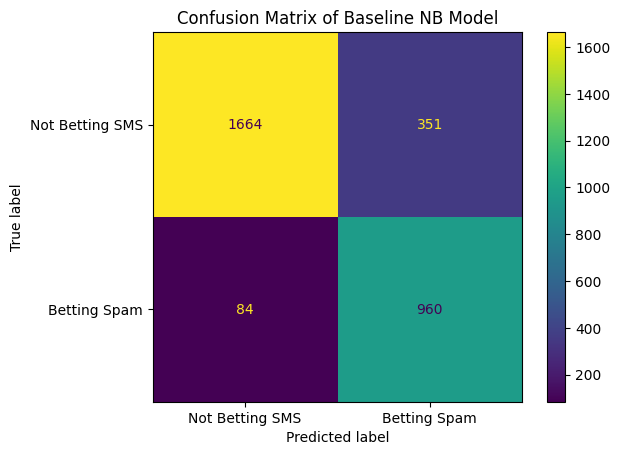

In [13]:
# confusion matrix of baseline model
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Betting SMS', 'Betting Spam']
)

disp.plot()
plt.title("Confusion Matrix of Baseline NB Model")
plt.show()

In [14]:
# decode GA chromosome to parameters
def decode_params(solution):
    alpha = abs(solution[0]) + 0.01
    ngram_choice = int(abs(solution[1])) % 2
    max_features_choice = int(abs(solution[2])) % 3
    stopword_choice = int(abs(solution[3])) % 2

    ngram_range = [(1,1), (1,2)][ngram_choice]
    max_features = [3000, 5000, None][max_features_choice]
    use_stopwords = [None, "english"][stopword_choice]

    return alpha, ngram_range, max_features, use_stopwords

In [15]:
# GA fit func
def fitness_func(ga_instance, solution, solution_idx):
    alpha, ngram_range, max_features, stopwords = decode_params(solution)

    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        stop_words=stopwords
    )

    x_train_vec = vectorizer.fit_transform(x_train_cleaned)
    x_test_vec = vectorizer.transform(x_test_cleaned)

    model = MultinomialNB(alpha=alpha)
    model.fit(x_train_vec, y_train)

    y_pred = model.predict(x_test_vec)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

In [16]:
# GA params
ga = pygad.GA(
    num_generations=20,
    num_parents_mating=6,
    sol_per_pop=12,
    num_genes=4,
    fitness_func=fitness_func,
    mutation_percent_genes=40
)

In [17]:
# Run GA
ga.run()

In [18]:
# get best solution
solution, solution_fitness, sol_idx = ga.best_solution()

print("Best GA solution parameters:", decode_params(solution))
print("Best Fitness (Accuracy):", solution_fitness)

best_alpha, best_ngram_range, best_max_features, best_stopwords = decode_params(solution)

ga_accuracy = ga.best_solution()[1]

Best GA solution parameters: (np.float64(0.032546204783186365), (1, 2), None, 'english')
Best Fitness (Accuracy): 0.9408303367113435


In [19]:
# train optimized model
vectorizer = TfidfVectorizer(
    ngram_range=best_ngram_range,
    max_features=best_max_features,
    stop_words=best_stopwords
)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test_cleaned)

final_model = MultinomialNB(alpha=best_alpha)
final_model.fit(x_train_vec, y_train)

y_pred = final_model.predict(x_test_vec)

print("Final Optimized Model Accuracy:")
print(accuracy_score(y_test, y_pred))

Final Optimized Model Accuracy:
0.9408303367113435


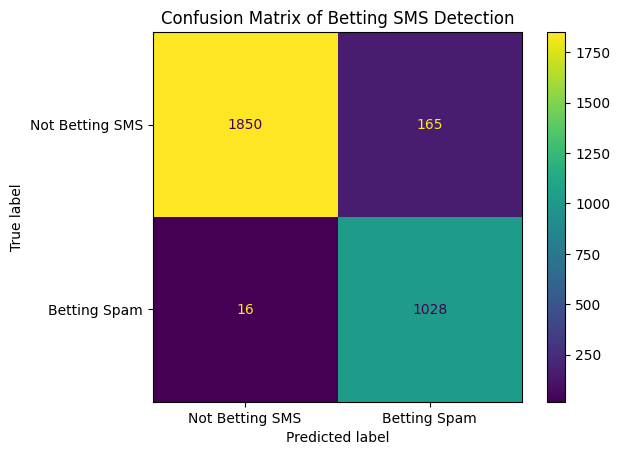

In [20]:
 # eval optimized model using confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Betting SMS', 'Betting Spam']
)

disp.plot()
plt.title("Confusion Matrix of Betting SMS Detection")
plt.show()

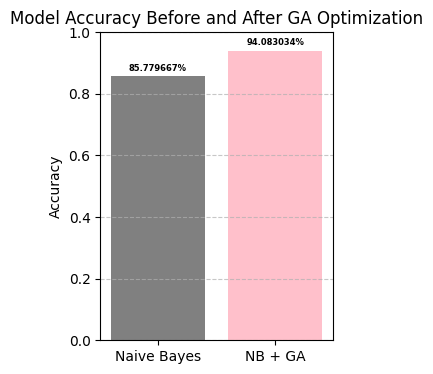

In [21]:
# bar chart comparison (vanilla nb vs nb+ga)

import matplotlib.pyplot as plt

accuracies = [baseline_accuracy, ga_accuracy]
labels = ['Naive Bayes', 'NB + GA']

plt.figure(figsize=(3,4))
bars = plt.bar(labels, accuracies, color=['gray', 'pink'])
for bar in bars:
    yval = bar.get_height()
    # Format the number to 2 decimal places and place it above the bar
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:2%}', 
             ha='center', 
             va='bottom',
             fontsize=6, 
             fontweight='bold')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Before and After GA Optimization')
plt.ylim(0, 1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\peaks\Documents\a\Code\betting-sms-detection-using-naive-bayes-ga\venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


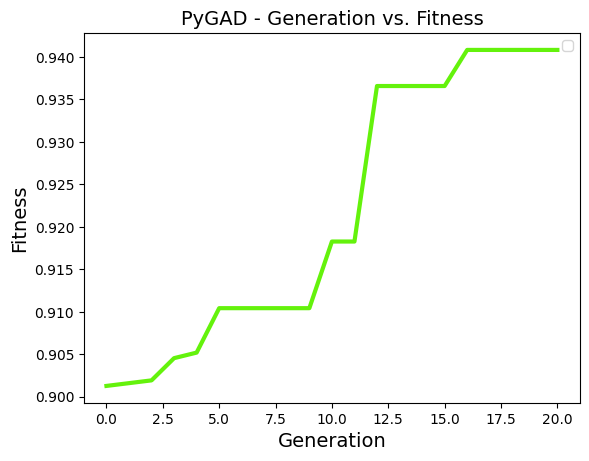

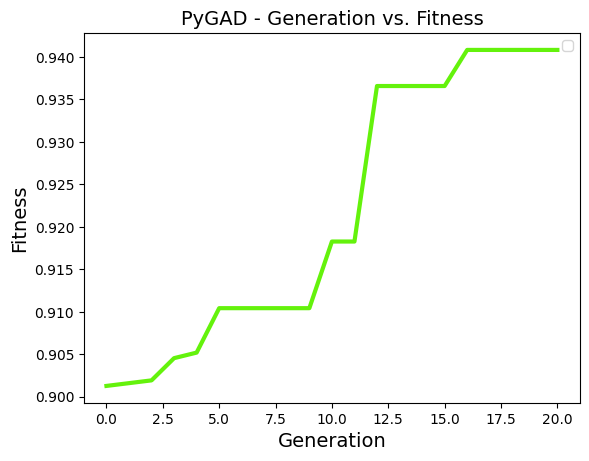

In [22]:
# show training, when/how it improved etc.
ga.plot_fitness()

In [23]:
# for saving model (delete later)
import pickle

# Save the CountVectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(cv, f)

# Save the trained model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
